# 4. 消费贷款违约风险预警

## 一、实验简介

本实验围绕 **消费金融风控（Consumer Credit Risk）** 场景展开，使用 Lending Club 公开贷款数据，比较 **树模型（LightGBM）** 与 **神经网络（MLP）** 在预测借款人违约或 charge-off 风险上的表现，并通过**时间切分（Temporal Split）** 评估模型的样本外预测能力与**数据漂移（Data Drift）** 问题。

**为什么同时使用树模型和神经网络？**

在消费金融风控实践中，模型选型是一个核心决策：

1. **LightGBM**：梯度提升树的高效实现，在结构化表格数据上通常表现优异，训练速度快，天然支持类别特征，是风控领域的主流选择。
2. **MLP（多层感知机）**：神经网络在捕捉高维非线性交互方面具有潜力，但在表格数据上并不总是优于树模型。通过对比，可以帮助学生理解"没有免费午餐定理"——没有哪种模型在所有场景下都最优。
3. **时间维度的考量**：真实风控系统面临的最大挑战不是"训练集上能做多好"，而是"未来数据与训练数据的分布是否一致"。时间切分训练和漂移分析是风控建模的核心实践。

本实验使用 **Lending Club 贷款数据集**，包含借款人的贷款信息、信用记录及还款状态。

## 二、实验目标

- 理解 LightGBM 的核心机制——**直方图加速（Histogram-based Splitting）**、**单边梯度采样（GOSS）** 和 **互斥特征捆绑（EFB）**。
- 掌握 MLP 的基本结构——**全连接层（Dense Layer）**、**激活函数（ReLU）**、**Dropout 正则化** 和 **批归一化（Batch Normalization）**。
- 理解**时间切分（Temporal Split）** 为何优于随机切分，以及如何通过时间切分模拟真实部署场景。
- 掌握**模型稳定性分析**方法：**PSI（Population Stability Index）** 和分时段 AUC 跟踪。
- 学会基于模型输出进行**客户风险分级**，形成可落地的风控方案。

## 三、实验要求

- 加载 Lending Club 贷款数据集并完成预处理。
- 按贷款发放时间进行训练集 / 测试集切分（而非随机切分）。
- 分别构建 LightGBM 模型和 MLP 模型。
- 对两个模型进行系统性评估与对比（AUC、KS、分类报告等）。
- 计算 PSI 分析模型输入特征和预测分数的稳定性。
- 基于预测概率对客户进行风险分级（如 A/B/C/D 四档），并分析各档的实际违约率。

## 四、思考提示

1. 为什么风控建模必须使用时间切分而不能使用随机切分？随机切分会带来什么问题？
2. LightGBM 相比 XGBoost 的核心改进是什么？在大规模数据上有何优势？
3. MLP 在表格数据上通常不如树模型，那它在什么场景下更有价值？
4. PSI > 0.25 意味着什么？当检测到严重漂移时，风控团队应该怎么做？
5. 客户分级的档位数量如何选择？分太多和分太少各有什么问题？

---

## 1. 环境准备

In [5]:
from __future__ import annotations

import shutil
import warnings
from pathlib import Path

import kagglehub
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib import font_manager
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

配置中文字体：

In [6]:
def configure_plot_fonts() -> None:
    """配置 matplotlib 中文字体，避免 seaborn 主题覆盖字体设置。"""
    sns.set_theme(style="whitegrid")
    font_candidates = [
        "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
        "PingFang SC", "WenQuanYi Zen Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    selected_font = next(
        (name for name in font_candidates if name in available_fonts), None
    )
    if selected_font is None:
        warnings.warn(
            "未检测到常见中文字体，图表中文可能显示为方块。"
            "建议安装 'Microsoft YaHei' 或 'Noto Sans CJK SC'。",
            UserWarning,
        )
        plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    else:
        plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


configure_plot_fonts()

---

## 2. 数据集加载与预处理

### 2.1 加载 Lending Club 数据

数据来源于 Lending Club 公开贷款数据，通过公开项目提供的序列化文件加载。

In [7]:
DATA_PATH = Path("data/lending_club_loan.csv")
if not DATA_PATH.exists():
    # ------------------------------------------------------------------
    # 方案 A：使用 kagglehub 自动下载（推荐）
    #   pip install kagglehub
    #   首次运行需配置 Kaggle API Token（~/.kaggle/kaggle.json）
    # 方案 B：手动下载
    #   访问 https://www.kaggle.com/datasets/janiobachmann/lending-club-first-dataset
    #   下载 CSV 并放置到工作目录，命名为 lending_club_loan.csv
    # ------------------------------------------------------------------
    try:
          # Ref: https://github.com/Kaggle/kagglehub
        dataset_dir = kagglehub.dataset_download(
            "janiobachmann/lending-club-first-dataset"
        )
        # kagglehub 返回下载目录，找到其中的 CSV 文件

        csv_files = list(Path(dataset_dir).glob("*.csv"))
        if not csv_files:
            raise FileNotFoundError(f"在 {dataset_dir} 中未找到 CSV 文件")
        shutil.copy(csv_files[0], DATA_PATH)
        print(f"已通过 kagglehub 下载数据至 {DATA_PATH}")
    except ImportError:
        raise RuntimeError(
            "本地未找到数据文件且未安装 kagglehub。\n"
            "请执行以下任一操作：\n"
            "  1. pip install kagglehub 并配置 Kaggle API Token\n"
            "  2. 手动从 https://www.kaggle.com/datasets/janiobachmann/"
            "lending-club-first-dataset 下载 CSV 至工作目录"
        )
df_raw = pd.read_csv(DATA_PATH)
print(f"原始数据集维度：{df_raw.shape}")
print(f"列名：{df_raw.columns.tolist()}")
df_raw.head()

原始数据集维度：(887379, 74)
列名：['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m',

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 目标变量定义与数据探索

在 Lending Club 数据中，`loan_status` 字段记录了贷款的最终状态。我们将其二值化为"违约/charge-off"与"正常还款"。

In [8]:
# 查看 loan_status 的分布
print("贷款状态分布：")
print(df_raw["loan_status"].value_counts())

贷款状态分布：
loan_status
Current                                                601779
Fully Paid                                             207723
Charged Off                                             45248
Late (31-120 days)                                      11591
Issued                                                   8460
In Grace Period                                          6253
Late (16-30 days)                                        2357
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [9]:
# 定义目标变量：Charged Off / Default 为正类（1），Fully Paid 为负类（0）
# 注意：根据实际数据集中的标签名称调整映射
STATUS_MAP = {
    "Fully Paid": 0,
    "Charged Off": 1,
}

# 仅保留明确为 Fully Paid 或 Charged Off 的记录
# 排除 Current、Late 等中间状态，因为这些贷款结果尚未确定
df = df_raw[df_raw["loan_status"].isin(STATUS_MAP.keys())].copy()
df["target"] = df["loan_status"].map(STATUS_MAP)

print(f"\n筛选后数据集维度：{df.shape}")
print(f"目标变量分布：\n{df['target'].value_counts()}")
print(f"违约率：{df['target'].mean():.4f}")


筛选后数据集维度：(252971, 75)
目标变量分布：
target
0    207723
1     45248
Name: count, dtype: int64
违约率：0.1789


### 2.3 特征工程

根据风控建模实践，选取对违约预测有业务意义的特征。

In [10]:
# 根据数据集实际可用列选取特征
# 以下为 Lending Club 数据集中常见的核心特征
CANDIDATE_FEATURES = [
    "loan_amnt",              # 贷款金额
    "term",                   # 贷款期限（36 或 60 个月）
    "int_rate",               # 利率
    "installment",            # 每月还款额
    "grade",                  # 信用等级（A-G）
    "sub_grade",              # 信用子等级
    "emp_length",             # 工作年限
    "home_ownership",         # 住房状况
    "annual_inc",             # 年收入
    "verification_status",    # 收入验证状态
    "purpose",                # 贷款用途
    "dti",                    # 债务收入比
    "open_acc",               # 开放信用账户数
    "pub_rec",                # 不良公共记录数
    "revol_bal",              # 循环信用余额
    "revol_util",             # 循环信用利用率
    "total_acc",              # 总信用账户数
    "mort_acc",               # 按揭账户数
    "pub_rec_bankruptcies",   # 破产记录数
]

# 根据实际数据集中存在的列进行筛选
FEATURES = [c for c in CANDIDATE_FEATURES if c in df.columns]
print(f"可用特征数量：{len(FEATURES)}")
print(f"可用特征：{FEATURES}")

# 检查缺失值
missing = df[FEATURES].isnull().sum()
print(f"\n缺失值统计（仅显示有缺失的列）：")
print(missing[missing > 0])

可用特征数量：17
可用特征：['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']

缺失值统计（仅显示有缺失的列）：
emp_length    9897
revol_util     199
dtype: int64


In [11]:
# 特征预处理
df_model = df[FEATURES + ["target"]].copy()

# 处理 term 列：提取数值（如 " 36 months" → 36）
if "term" in df_model.columns:
    df_model["term"] = (
        df_model["term"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .astype(float)
    )

# 处理 emp_length 列：提取数值（如 "10+ years" → 10, "< 1 year" → 0）
if "emp_length" in df_model.columns:
    df_model["emp_length"] = (
        df_model["emp_length"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .astype(float)
    )

# 对分类特征进行 Label Encoding
label_encoders = {}
cat_cols = df_model[FEATURES].select_dtypes(include=["object", "category"]).columns.tolist()
print(f"分类特征：{cat_cols}")

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# 填充缺失值（使用中位数填充数值特征）
df_model[FEATURES] = df_model[FEATURES].fillna(df_model[FEATURES].median())

print(f"\n预处理后数据维度：{df_model.shape}")
print(f"剩余缺失值：{df_model[FEATURES].isnull().sum().sum()}")

分类特征：['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']

预处理后数据维度：(252971, 18)
剩余缺失值：0


### 2.4 时间切分训练集与测试集

**为什么使用时间切分？** 在真实风控场景中，模型永远是用"历史数据"训练、对"未来客户"预测。随机切分会导致**数据泄漏（Data Leakage）**——模型在训练时"偷看"了未来的信息，导致测试集上的表现虚高，上线后性能骤降。

时间切分模拟了真实部署场景：用过去的数据建模，在未来的数据上验证。

In [12]:
# Lending Club 数据中通常包含 issue_d（贷款发放日期）字段
# 如果数据集中存在该字段，按时间排序后切分
if "issue_d" in df.columns:
    df_model["issue_d"] = pd.to_datetime(df["issue_d"].values)
    df_model = df_model.sort_values("issue_d").reset_index(drop=True)

    # 按时间 80/20 切分（前 80% 时间段为训练集，后 20% 为测试集）
    split_idx = int(len(df_model) * 0.8)
    train_df = df_model.iloc[:split_idx]
    test_df = df_model.iloc[split_idx:]

    print(f"训练集时间范围：{train_df['issue_d'].min()} ~ {train_df['issue_d'].max()}")
    print(f"测试集时间范围：{test_df['issue_d'].min()} ~ {test_df['issue_d'].max()}")
else:
    # 如果没有时间字段，退回到按索引顺序切分（假设数据已按时间排列）
    # 并给出警告
    warnings.warn(
        "数据集中未找到 'issue_d' 列，将按索引顺序进行 80/20 切分。"
        "请确认数据是否已按时间排序，否则结果可能不可靠。",
        UserWarning,
    )
    split_idx = int(len(df_model) * 0.8)
    train_df = df_model.iloc[:split_idx]
    test_df = df_model.iloc[split_idx:]

X_train = train_df[FEATURES]
y_train = train_df["target"]
X_test = test_df[FEATURES]
y_test = test_df["target"]

print(f"\n训练集大小：{X_train.shape[0]}，违约率：{y_train.mean():.4f}")
print(f"测试集大小：{X_test.shape[0]}，违约率：{y_test.mean():.4f}")

训练集时间范围：2007-06-01 00:00:00 ~ 2014-07-01 00:00:00
测试集时间范围：2014-07-01 00:00:00 ~ 2015-12-01 00:00:00

训练集大小：202376，违约率：0.1859
测试集大小：50595，违约率：0.1508


> **观察训练集和测试集的违约率是否存在差异**。如果差异明显，说明数据存在**目标漂移（Label Drift）**，这正是时间切分能暴露而随机切分无法发现的问题。

---

## 3. 核心概念

### 3.1 LightGBM

LightGBM 是微软开源的梯度提升框架，相比 XGBoost 有三项关键改进：

- **直方图加速（Histogram-based Splitting）**：将连续特征离散化为固定数量的桶（bins），大幅降低分裂点搜索的计算复杂度，从 O(#data × #features) 降至 O(#bins × #features)。
- **单边梯度采样（GOSS, Gradient-based One-Side Sampling）**：保留所有梯度大的样本（训练效果差的"困难样本"），对梯度小的样本进行随机采样，在不显著损失精度的前提下加速训练。
- **互斥特征捆绑（EFB, Exclusive Feature Bundling）**：将互斥的稀疏特征捆绑为单一特征，减少有效特征数量。

**LightGBM 在风控中的优势**：
- ✅ 训练速度极快，适合百万级以上数据。
- ✅ 原生支持类别特征（无需手动 Label Encoding）。
- ✅ 内置处理缺失值。
- ✅ 支持特征重要性提取和 SHAP 解释。

### 3.2 MLP（多层感知机）

MLP 是最基本的前馈神经网络结构，由多个全连接层（Dense Layer）堆叠而成。

**MLP 的核心组件**：
- **全连接层（Linear Layer）**：每个神经元与上一层所有神经元相连，执行线性变换 y = Wx + b。
- **激活函数（ReLU）**：引入非线性，使网络能拟合复杂模式。ReLU(x) = max(0, x)。
- **Dropout**：训练时随机"关闭"一部分神经元，防止过拟合。
- **批归一化（Batch Normalization）**：对每一层的输入进行归一化，加速训练并提高稳定性。

**MLP 在表格数据上的局限**：
- ❌ 通常不如集成树模型（需要仔细调参才能接近）。
- ❌ 需要特征标准化。
- ❌ 训练时间较长，对超参数敏感。
- ✅ 但在特征交互极其复杂、或需要端到端学习的场景中可能有优势。

### 3.3 时间切分与数据漂移

**时间切分（Temporal Split）**：按时间顺序将数据分为训练集（过去）和测试集（未来），模拟真实部署场景。

**数据漂移（Data Drift）** 是指模型部署后，新数据的分布与训练数据发生了偏移。在消费金融场景中，漂移的常见原因包括：
- 宏观经济变化（如经济衰退导致整体违约率上升）。
- 客群结构变化（如营销策略调整引入了不同特征的客户）。
- 政策变化（如利率调整、审批标准变化）。

**PSI（Population Stability Index）** 是衡量分布漂移的标准指标：

| PSI 值 | 含义 |
|--------|------|
| < 0.10 | 分布稳定，无显著漂移 |
| 0.10 – 0.25 | 轻微漂移，需要关注 |
| > 0.25 | 显著漂移，模型可能需要重新训练 |

### 3.4 KS 统计量

**KS（Kolmogorov-Smirnov）统计量** 是风控领域最常用的模型区分度指标之一，衡量的是模型对正负样本的**最大累积分布差异**。

| KS 值 | 含义 |
|-------|------|
| > 0.40 | 优秀 |
| 0.30 – 0.40 | 良好 |
| 0.20 – 0.30 | 一般 |
| < 0.20 | 较差 |

---

## 4. 构建 LightGBM 模型

### 4.1 训练 LightGBM

在这一节，我们先关注 **LightGBM 如何完成二分类学习**。

- 本质上它在迭代地训练多棵决策树，让后续树去修正前一轮的预测误差。
- 训练目标是让模型输出的违约概率尽可能贴近真实标签。
- `early_stopping` 的意义是：当验证集表现长期不再提升时提前停止，避免过拟合。

阅读代码时，重点观察两件事：
1. **复杂度控制参数**（如 `max_depth`、`num_leaves`、正则项）；
2. **泛化控制策略**（如 `subsample`、`colsample_bytree`、早停）。

In [13]:
# Ref: https://lightgbm.readthedocs.io/en/latest/pythonAPI/lightgbm.LGBMClassifier.html
lgb_clf = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,            # 叶子节点数，控制模型复杂度
    subsample=0.8,            # 行采样比例（类似 Bagging）
    colsample_bytree=0.8,     # 列采样比例
    reg_alpha=0.1,            # L1 正则化
    reg_lambda=0.1,           # L2 正则化
    is_unbalance=True,        # 处理类别不平衡
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ],
)

y_pred_lgb = lgb_clf.predict(X_test)
y_prob_lgb = lgb_clf.predict_proba(X_test)[:, 1]

print("\n=== LightGBM 模型评估 ===")
print(classification_report(y_test, y_pred_lgb, target_names=["正常还款", "违约/Charge-off"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lgb):.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.427549

=== LightGBM 模型评估 ===
               precision    recall  f1-score   support

         正常还款       0.85      1.00      0.92     42966
违约/Charge-off       0.00      0.00      0.00      7629

     accuracy                           0.85     50595
    macro avg       0.42      0.50      0.46     50595
 weighted avg       0.72      0.85      0.78     50595

AUC-ROC: 0.6940


### 4.2 LightGBM 特征重要性

特征重要性用于回答一个教学上非常关键的问题：**模型主要依赖了哪些变量做判断？**

本节使用的是基于分裂次数（split count）的重要性：某特征被用于分裂的次数越多，重要性越高。

需要提醒学生：
- 重要性高不等于因果关系强；
- 高相关特征可能“分摊”重要性，导致单个特征看起来不高；
- 不同重要性口径（split、gain、SHAP）结论可能不同。

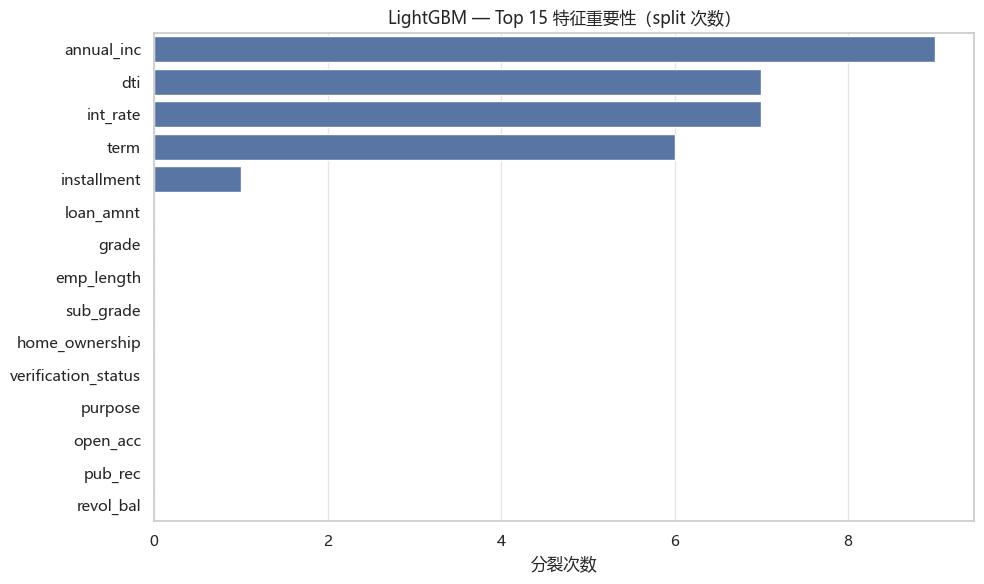

In [14]:
lgb_importance = pd.Series(
    lgb_clf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
top15 = lgb_importance.head(15)
sns.barplot(x=top15.values, y=top15.index)
plt.title("LightGBM — Top 15 特征重要性（split 次数）")
plt.xlabel("分裂次数")
plt.ylabel("")
plt.tight_layout()
plt.show()

---

## 5. 构建 MLP 模型

### 5.1 数据标准化

MLP 对输入特征的尺度敏感。与树模型不同，神经网络要求输入特征在相近的数值范围内，否则梯度更新会不均匀，导致训练困难。

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # 注意：只能用训练集的统计量来变换测试集

# 转换为 PyTorch 张量
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备：{device}")

X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

使用设备：cuda


### 5.2 定义 MLP 网络结构

这一节的目标是让学生理解：**网络结构本身就是“假设空间”的设计**。

- 层数和每层神经元数量决定模型容量；
- `ReLU` 提供非线性表达能力；
- `BatchNorm` 稳定训练过程；
- `Dropout` 抑制过拟合、提升泛化能力。

教学上可引导学生思考：如果隐藏层太小会欠拟合，太大又可能过拟合，如何通过验证集指标来平衡。

In [16]:
# Ref: https://pytorch.org/docs/stable/nn.html
class MLPClassifier(nn.Module):
    """用于二分类的多层感知机。

    结构：Input → [Linear → BN → ReLU → Dropout] × 3 → Linear → Sigmoid
    """

    def __init__(self, input_dim: int, hidden_dims: list[int] = None, dropout: float = 0.3):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]

        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


input_dim = X_train_scaled.shape[1]
mlp_model = MLPClassifier(input_dim=input_dim, hidden_dims=[128, 64, 32], dropout=0.3).to(device)

print(mlp_model)
print(f"\n模型参数总数：{sum(p.numel() for p in mlp_model.parameters()):,}")

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

模型参数总数：13,121


### 5.3 训练 MLP

这里关注 **“模型如何被优化出来”**：通过损失函数衡量预测误差，再用优化器迭代更新参数。

- `BCELoss` 对应二分类交叉熵，衡量预测概率与真实标签差距；
- `Adam` 通过自适应学习率加速收敛；
- `ReduceLROnPlateau` 在损失停滞时自动降低学习率，帮助模型继续细化。

同时要提醒：当前实现使用了 `Sigmoid + BCELoss`。在工业实践中常见更稳健的写法是 `BCEWithLogitsLoss`。

In [17]:
# 使用 BCELoss（二元交叉熵）作为损失函数
# 对不平衡数据，使用 pos_weight 加权正类
pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
criterion = nn.BCELoss(
    weight=None  # BCELoss 不直接支持 pos_weight，改用下面的方式
)

# 更好的做法：使用 BCEWithLogitsLoss + pos_weight
# 但这里为了教学清晰，先用简单的 BCELoss
# Ref: https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

NUM_EPOCHS = 50
train_losses = []
val_aucs = []

for epoch in range(NUM_EPOCHS):
    # 训练阶段
    mlp_model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred_batch = mlp_model(X_batch)
        loss = criterion(y_pred_batch, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(y_batch)
    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)

    # 验证阶段
    mlp_model.eval()
    with torch.no_grad():
        y_prob_val = mlp_model(X_test_tensor).cpu().numpy()
        val_auc = roc_auc_score(y_test, y_prob_val)
        val_aucs.append(val_auc)

    scheduler.step(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {epoch_loss:.4f} | Val AUC: {val_auc:.4f}")

Epoch  10/50 | Loss: 0.4414 | Val AUC: 0.7096
Epoch  20/50 | Loss: 0.4400 | Val AUC: 0.7099
Epoch  30/50 | Loss: 0.4396 | Val AUC: 0.7135
Epoch  40/50 | Loss: 0.4398 | Val AUC: 0.7144
Epoch  50/50 | Loss: 0.4387 | Val AUC: 0.7134


### 5.4 训练过程可视化

训练曲线是判断模型状态的“体检报告”：

- 若训练损失持续下降但验证 AUC 下降，通常是过拟合信号；
- 若两者都长期无改善，可能是欠拟合或学习率设置不合理；
- 若验证 AUC 波动很大，可能与样本噪声、批大小或学习率有关。

建议学生不要只看最后一个 epoch，而要观察整体趋势。

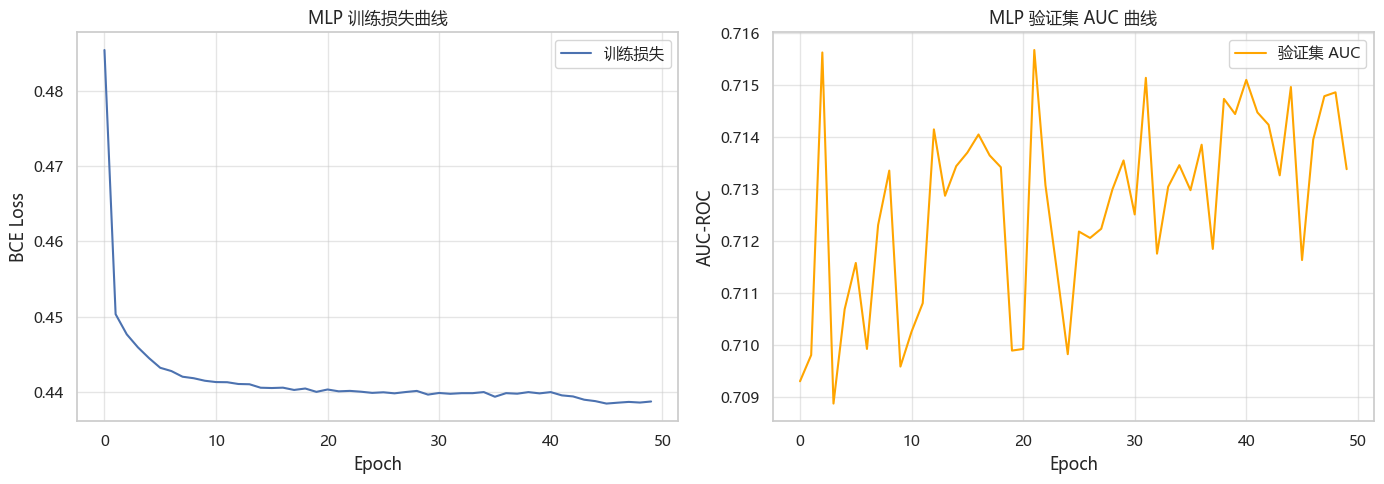

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="训练损失")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("MLP 训练损失曲线")
ax1.legend()

ax2.plot(val_aucs, label="验证集 AUC", color="orange")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC-ROC")
ax2.set_title("MLP 验证集 AUC 曲线")
ax2.legend()

plt.tight_layout()
plt.show()

### 5.5 MLP 预测

这一节将连续概率转为离散类别（默认阈值 0.5），并输出分类报告。

教学重点：
- `y_prob_mlp` 是“风险强度”（连续值）；
- `y_pred_mlp` 是“决策结果”（离散标签）；
- 在风控场景中，阈值通常不是固定 0.5，而是结合业务成本（坏账损失 vs. 错拒成本）动态选择。

In [19]:
mlp_model.eval()
with torch.no_grad():
    y_prob_mlp = mlp_model(X_test_tensor).cpu().numpy()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

print("=== MLP 模型评估 ===")
print(classification_report(y_test, y_pred_mlp, target_names=["正常还款", "违约/Charge-off"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_mlp):.4f}")

=== MLP 模型评估 ===
               precision    recall  f1-score   support

         正常还款       0.85      1.00      0.92     42966
违约/Charge-off       0.50      0.02      0.03      7629

     accuracy                           0.85     50595
    macro avg       0.68      0.51      0.47     50595
 weighted avg       0.80      0.85      0.78     50595

AUC-ROC: 0.7134


---

## 6. 模型对比与评估

### 6.1 ROC 曲线对比

ROC 曲线用于观察模型在**不同阈值**下的整体区分能力：

- 横轴 FPR（假正率），纵轴 TPR（召回率）；
- 曲线越靠左上角，说明模型在较低误报下获得较高召回；
- AUC 是 ROC 的面积，越接近 1 代表排序能力越强。

它的优势是与具体阈值解耦，适合先比较模型“潜在上限”。

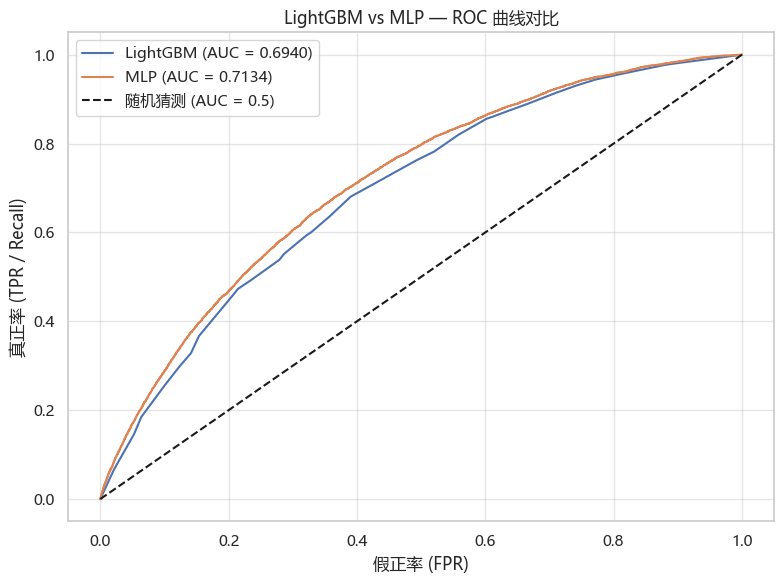

In [20]:
plt.figure(figsize=(8, 6))

for name, y_prob in [("LightGBM", y_prob_lgb), ("MLP", y_prob_mlp)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="随机猜测 (AUC = 0.5)")
plt.xlabel("假正率 (FPR)")
plt.ylabel("真正率 (TPR / Recall)")
plt.title("LightGBM vs MLP — ROC 曲线对比")
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 KS 统计量计算

KS（Kolmogorov-Smirnov）衡量的是：在所有可能阈值下，正负样本累积分布差异的最大值。

在风控中，KS 常用于评估模型“把好客户和坏客户拉开距离”的能力：
- KS 越大，区分度通常越好；
- 同时输出“最优阈值”，可作为后续策略分层的参考起点。

In [21]:
def compute_ks(y_true: np.ndarray, y_prob: np.ndarray) -> tuple[float, float]:
    """计算 KS 统计量及对应的最优阈值。"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks_values = tpr - fpr
    ks_max = ks_values.max()
    ks_threshold = thresholds[ks_values.argmax()]
    return ks_max, ks_threshold


ks_lgb, thresh_lgb = compute_ks(y_test.values, y_prob_lgb)
ks_mlp, thresh_mlp = compute_ks(y_test.values, y_prob_mlp)

print(f"LightGBM KS: {ks_lgb:.4f}（最优阈值: {thresh_lgb:.4f}）")
print(f"MLP      KS: {ks_mlp:.4f}（最优阈值: {thresh_mlp:.4f}）")

LightGBM KS: 0.2903（最优阈值: 0.2038）
MLP      KS: 0.3144（最优阈值: 0.1963）


### 6.3 评估指标汇总

单一指标容易片面，因此这里汇总 Accuracy、Precision、Recall、F1、AUC、KS 进行多维比较。

建议从业务视角解读：
- 若更关注“少放坏账”，应关注 Precision 与 KS；
- 若更关注“尽量识别高风险客户”，应关注 Recall；
- F1 适合在 Precision/Recall 需要平衡时参考。

教学上要强调：**没有放之四海而皆准的最优指标，取决于业务目标。**

In [22]:
results = []
for name, y_pred, y_prob in [
    ("LightGBM", y_pred_lgb, y_prob_lgb),
    ("MLP", y_pred_mlp, y_prob_mlp),
]:
    ks_val, _ = compute_ks(y_test.values, y_prob)
    results.append({
        "模型": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_prob), 4),
        "KS": round(ks_val, 4),
    })

results_df = pd.DataFrame(results)
print("\n=== 模型评估指标汇总 ===")
display(results_df)


=== 模型评估指标汇总 ===


,模型,Accuracy,Precision,Recall,F1 Score,AUC-ROC,KS
0,LightGBM,0.8492,0.0000,0.0000,0.00,0.6940,0.2903
1,MLP,0.8492,0.5021,0.0155,0.03,0.7134,0.3144


### 6.4 混淆矩阵对比

混淆矩阵把预测结果拆成 TP/FP/FN/TN 四类，能直观看到模型错误发生在哪一侧。

在信贷场景中两类错误的代价不同：
- **FP（把好客户判成坏客户）**：损失业务机会；
- **FN（把坏客户判成好客户）**：带来真实坏账风险。

因此，混淆矩阵常用于和业务团队共同确定阈值与审批策略。

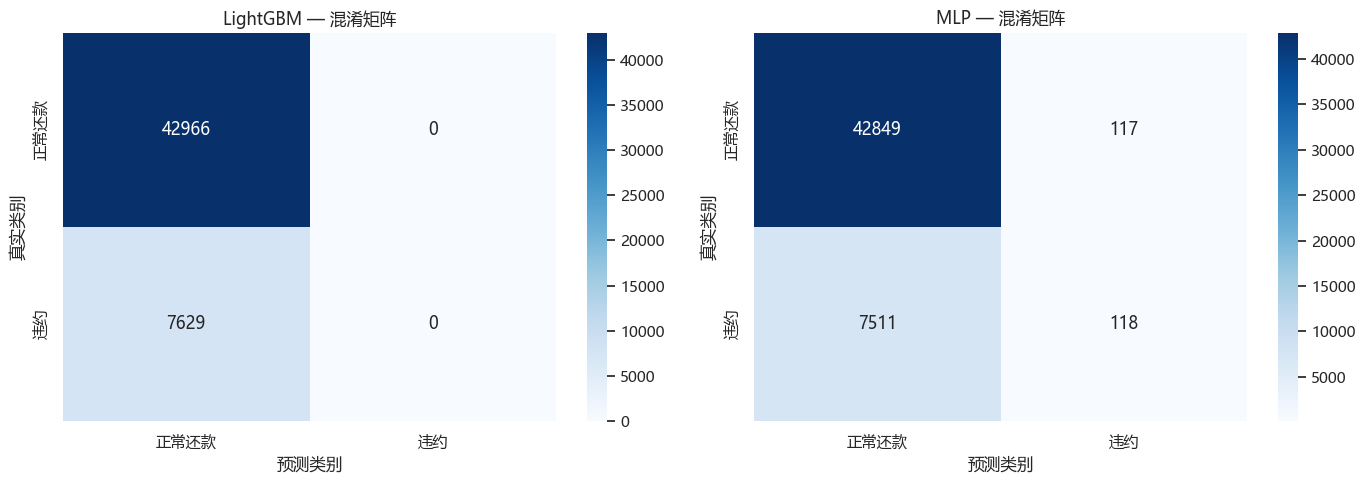

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, name in [
    (axes[0], y_pred_lgb, "LightGBM"),
    (axes[1], y_pred_mlp, "MLP"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["正常还款", "违约"], yticklabels=["正常还款", "违约"])
    ax.set_title(f"{name} — 混淆矩阵")
    ax.set_xlabel("预测类别")
    ax.set_ylabel("真实类别")

plt.tight_layout()
plt.show()

---

## 7. 模型稳定性分析（PSI）

### 7.1 PSI 计算

PSI 衡量两个分布之间的差异，计算公式为：

$$\text{PSI} = \sum_{i=1}^{N} \left( P_i^{\text{actual}} - P_i^{\text{expected}} \right) \times \ln\left(\frac{P_i^{\text{actual}}}{P_i^{\text{expected}}}\right)$$

其中将预测分数分成 N 个桶（bin），比较训练集和测试集在每个桶中的样本占比。

In [24]:
def compute_psi(expected: np.ndarray, actual: np.ndarray, n_bins: int = 10) -> float:
    """计算 Population Stability Index (PSI)。

    Parameters
    ----------
    expected : 基准分布（训练集预测分数）
    actual   : 待比较分布（测试集预测分数）
    n_bins   : 分桶数量

    Returns
    -------
    PSI 值
    """
    # 基于 expected 的分位数确定桶边界
    breakpoints = np.quantile(expected, np.linspace(0, 1, n_bins + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    psi = 0.0
    for i in range(n_bins):
        mask_exp = (expected >= breakpoints[i]) & (expected < breakpoints[i + 1])
        mask_act = (actual >= breakpoints[i]) & (actual < breakpoints[i + 1])

        pct_exp = mask_exp.sum() / len(expected)
        pct_act = mask_act.sum() / len(actual)

        # 避免除零和 log(0)
        pct_exp = max(pct_exp, 1e-6)
        pct_act = max(pct_act, 1e-6)

        psi += (pct_act - pct_exp) * np.log(pct_act / pct_exp)

    return psi

### 7.2 预测分数的 PSI

In [25]:
# 计算训练集上的预测分数（作为基准）
y_prob_train_lgb = lgb_clf.predict_proba(X_train)[:, 1]

mlp_model.eval()
with torch.no_grad():
    y_prob_train_mlp = mlp_model(X_train_tensor).cpu().numpy()

# 计算 PSI
psi_lgb = compute_psi(y_prob_train_lgb, y_prob_lgb, n_bins=10)
psi_mlp = compute_psi(y_prob_train_mlp, y_prob_mlp, n_bins=10)

print(f"LightGBM 预测分数 PSI: {psi_lgb:.4f}")
print(f"MLP      预测分数 PSI: {psi_mlp:.4f}")
print()

for name, psi_val in [("LightGBM", psi_lgb), ("MLP", psi_mlp)]:
    if psi_val < 0.10:
        status = "✅ 稳定"
    elif psi_val < 0.25:
        status = "⚠️ 轻微漂移"
    else:
        status = "🚨 显著漂移"
    print(f"{name}: PSI = {psi_val:.4f} → {status}")

LightGBM 预测分数 PSI: 0.0161
MLP      预测分数 PSI: 0.0306

LightGBM: PSI = 0.0161 → ✅ 稳定
MLP: PSI = 0.0306 → ✅ 稳定


### 7.3 关键特征的 PSI

In [26]:
# 检查关键输入特征在训练集和测试集之间是否发生漂移
feature_psi = {}
for feat in FEATURES:
    psi_val = compute_psi(
        X_train[feat].values.astype(float),
        X_test[feat].values.astype(float),
        n_bins=10,
    )
    feature_psi[feat] = psi_val

feature_psi_df = (
    pd.Series(feature_psi, name="PSI")
    .sort_values(ascending=False)
    .to_frame()
)
feature_psi_df["状态"] = feature_psi_df["PSI"].apply(
    lambda x: "🚨 显著漂移" if x > 0.25 else ("⚠️ 轻微漂移" if x > 0.10 else "✅ 稳定")
)

print("=== 特征 PSI 分析 ===")
display(feature_psi_df)

=== 特征 PSI 分析 ===


,PSI,状态
verification_status,0.085499,✅ 稳定
sub_grade,0.077314,✅ 稳定
grade,0.071669,✅ 稳定
pub_rec,0.060990,✅ 稳定
dti,0.060840,✅ 稳定
open_acc,0.038918,✅ 稳定
revol_util,0.037484,✅ 稳定
total_acc,0.034726,✅ 稳定
term,0.030266,✅ 稳定
int_rate,0.026570,✅ 稳定


### 7.4 预测分数分布对比可视化

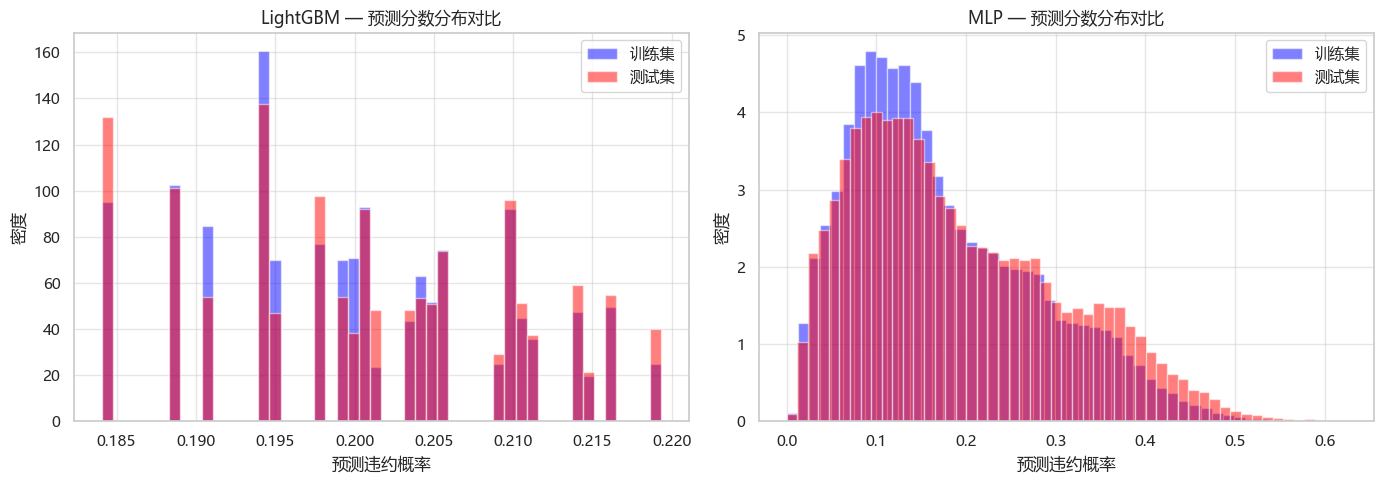

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prob_train, prob_test, name in [
    (axes[0], y_prob_train_lgb, y_prob_lgb, "LightGBM"),
    (axes[1], y_prob_train_mlp, y_prob_mlp, "MLP"),
]:
    ax.hist(prob_train, bins=50, alpha=0.5, density=True, label="训练集", color="blue")
    ax.hist(prob_test, bins=50, alpha=0.5, density=True, label="测试集", color="red")
    ax.set_title(f"{name} — 预测分数分布对比")
    ax.set_xlabel("预测违约概率")
    ax.set_ylabel("密度")
    ax.legend()

plt.tight_layout()
plt.show()

---

## 8. 客户风险分级

### 8.1 基于预测概率的分级方案

在实际风控业务中，模型的输出概率会被转化为**客户风险等级**，用于差异化的信贷策略（如额度、利率、人工审核等）。

In [28]:
def assign_risk_grade(prob: np.ndarray, n_grades: int = 4) -> np.ndarray:
    """基于预测违约概率将客户分为 A/B/C/D 四个风险等级。

    A 级：风险最低（概率最小的 25%）
    D 级：风险最高（概率最大的 25%）
    """
    grade_labels = [chr(ord("A") + i) for i in range(n_grades)]  # ['A', 'B', 'C', 'D']
    # 使用分位数确定分级边界
    boundaries = np.quantile(prob, np.linspace(0, 1, n_grades + 1))
    grades = np.digitize(prob, boundaries[1:-1])  # 0, 1, 2, 3
    return np.array([grade_labels[min(g, n_grades - 1)] for g in grades])


# 使用 LightGBM 的预测概率进行分级
risk_grades = assign_risk_grade(y_prob_lgb, n_grades=4)

grade_analysis = pd.DataFrame({
    "风险等级": risk_grades,
    "实际违约": y_test.values,
    "预测概率": y_prob_lgb,
})

grade_summary = grade_analysis.groupby("风险等级").agg(
    客户数量=("实际违约", "count"),
    实际违约率=("实际违约", "mean"),
    平均预测概率=("预测概率", "mean"),
    最小预测概率=("预测概率", "min"),
    最大预测概率=("预测概率", "max"),
).round(4)

print("=== 客户风险分级分析（LightGBM）===")
display(grade_summary)

=== 客户风险分级分析（LightGBM）===


,客户数量,实际违约率,平均预测概率,最小预测概率,最大预测概率
风险等级,,,,,
A,11693,0.0458,0.1879,0.1841,0.1941
B,11932,0.1073,0.1970,0.1942,0.2001
C,14140,0.1559,0.2037,0.2006,0.2093
D,12830,0.2813,0.2130,0.2098,0.2193


### 8.2 分级效果可视化

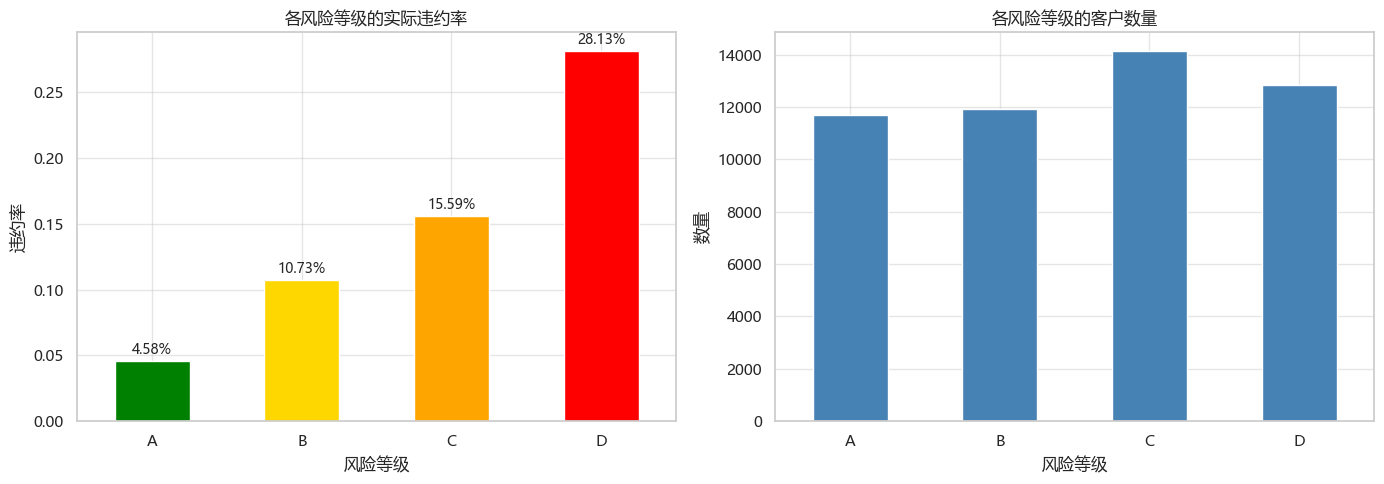

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 各等级实际违约率
grade_summary["实际违约率"].plot(kind="bar", ax=ax1, color=["green", "gold", "orange", "red"])
ax1.set_title("各风险等级的实际违约率")
ax1.set_xlabel("风险等级")
ax1.set_ylabel("违约率")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
for i, v in enumerate(grade_summary["实际违约率"]):
    ax1.text(i, v + 0.005, f"{v:.2%}", ha="center", fontsize=10)

# 各等级客户数量
grade_summary["客户数量"].plot(kind="bar", ax=ax2, color="steelblue")
ax2.set_title("各风险等级的客户数量")
ax2.set_xlabel("风险等级")
ax2.set_ylabel("数量")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**好的分级方案**应满足：A 级违约率远低于 D 级，且各等级的违约率呈单调递增。如果出现"倒挂"（即低风险等级反而违约率更高），说明模型的区分能力存在问题。

---

## 9. 实验结论

### 9.1 模型对比总结

| 维度 | LightGBM | MLP |
|------|----------|-----|
| **训练速度** | 快，支持大规模数据 | 较慢，需要 GPU 加速 |
| **调参难度** | 中等，超参数含义直观 | 较高，对学习率、网络结构等敏感 |
| **可解释性** | 支持特征重要性和 SHAP | 黑盒模型，需要额外解释工具 |
| **表格数据表现** | 通常更优 | 通常略逊，但差距因数据而异 |
| **对特征工程的依赖** | 较低 | 需要标准化，对特征质量更敏感 |

### 9.2 时间切分的价值

通过时间切分，我们能够：
- 模拟真实的模型部署场景。
- 暴露训练集和测试集之间的分布差异（数据漂移）。
- 获得更真实的样本外性能评估。

### 9.3 模型稳定性的重要性

PSI 分析帮助我们识别：
- 哪些特征发生了显著漂移，可能导致模型性能下降。
- 模型的预测分数分布是否稳定。
- 是否需要触发模型重训练。

### 9.4 客户分级的业务落地

风险分级是模型从"实验室"到"生产线"的关键桥梁。通过将连续的预测概率转化为离散的风险等级，业务团队可以制定清晰、可执行的差异化策略。

---

## 10. 课堂思考题

1. 如果训练集和测试集的违约率差异超过 5 个百分点，这对模型评估意味着什么？应如何处理？
2. LightGBM 的 `num_leaves` 和 `max_depth` 分别如何控制模型复杂度？两者的关系是什么？
3. MLP 的 Dropout 比例设置为多少比较合适？如果设置为 0 和 0.8 分别会发生什么？
4. 如果某个特征的 PSI > 0.25，应该直接删除这个特征吗？还是有更好的处理方式？
5. 客户风险分级为什么通常使用 4-5 档而不是 10 档或 2 档？从业务和统计两个角度分析。
6. 在实际风控系统中，模型多久需要重新训练一次？触发重训练的信号有哪些？

---

## 11. 实验报告要求

本实验要求提交一份 **消费金融风险预警报告**，包含以下内容：

| 章节 | 内容 |
|------|------|
| **数据概览** | 数据集基本信息、目标变量分布、关键特征描述性统计 |
| **模型建设** | LightGBM 与 MLP 的训练过程、超参数选择理由 |
| **模型评估** | AUC、KS、F1、混淆矩阵等指标对比，ROC 曲线图 |
| **稳定性分析** | 预测分数 PSI、关键特征 PSI、漂移原因分析 |
| **客户分级方案** | 分级逻辑、各等级违约率验证、差异化风控策略建议 |
| **结论与建议** | 推荐模型选择、模型监控方案、模型迭代计划 |